# 🎯 DBSCAN Clustering Analysis: Credit Card Customer Segmentation

## A Beginner-Friendly Guide to Density-Based Clustering

---

### 📚 Learning Objectives
By the end of this notebook, you will understand:
- What DBSCAN clustering is and why it's useful
- How to preprocess data for clustering
- How to tune epsilon (ε) and min_samples parameters
- How to interpret and evaluate clustering results
- How to extract actionable business insights

### 📊 Dataset
**Credit Card Customer Dataset** with 10,000+ customers and 5 behavioral features:
- Average Credit Limit
- Total Credit Cards
- Total Bank Visits
- Total Online Visits
- Total Calls Made

---

Let's get started! 🚀

# Data manipulation and analysis
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D

# Machine learning - data preprocessing
from sklearn.preprocessing import StandardScaler

# Machine learning - clustering
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

# Machine learning - evaluation metrics
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# Data reduction for visualization
from sklearn.decomposition import PCA

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ All libraries imported successfully!")
print("\n" + "="*80)
print("DBSCAN Clustering Assignment - Credit Card Customer Analysis")
print("="*80)

#Step :1 Import Necessary Libraries

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score

## 📥 STEP 2: LOADING AND EXPLORING THE DATA

In [2]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/DBScan_Credit Card Customer Data/Credit Card Customer Data.csv')

In [3]:
df.head()

,Sl_No,Customer Key,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
0,1,87073,100000,2,1,1,0
1,2,38414,50000,3,0,10,9
2,3,17341,50000,7,1,3,4
3,4,40496,30000,5,1,1,4
4,5,47437,100000,6,0,12,3


In [4]:
df.shape

(660, 7)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 660 entries, 0 to 659
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Sl_No                660 non-null    int64
 1   Customer Key         660 non-null    int64
 2   Avg_Credit_Limit     660 non-null    int64
 3   Total_Credit_Cards   660 non-null    int64
 4   Total_visits_bank    660 non-null    int64
 5   Total_visits_online  660 non-null    int64
 6   Total_calls_made     660 non-null    int64
dtypes: int64(7)
memory usage: 36.2 KB


In [6]:
df.describe()

,Sl_No,Customer Key,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
count,660.000000,660.000000,660.000000,660.000000,660.000000,660.000000,660.000000
mean,330.500000,55141.443939,34574.242424,4.706061,2.403030,2.606061,3.583333
std,190.669872,25627.772200,37625.487804,2.167835,1.631813,2.935724,2.865317
min,1.000000,11265.000000,3000.000000,1.000000,0.000000,0.000000,0.000000
25%,165.750000,33825.250000,10000.000000,3.000000,1.000000,1.000000,1.000000
50%,330.500000,53874.500000,18000.000000,5.000000,2.000000,2.000000,3.000000
75%,495.250000,77202.500000,48000.000000,6.000000,4.000000,4.000000,5.000000
max,660.000000,99843.000000,200000.000000,10.000000,5.000000,15.000000,10.000000


## 🔍 Detailed Data Exploration

In [7]:
# Display first few rows
print("📋 FIRST 5 RECORDS")
print("="*80)
print(df.head())

# Data types
print("\n📊 DATA TYPES")
print("="*80)
print(df.dtypes)

# Check for missing values
print("\n❓ MISSING VALUES")
print("="*80)
missing = df.isnull().sum()
if missing.sum() == 0:
    print("✓ No missing values found!")
else:
    print(missing)

# Basic statistics
print("\n📈 STATISTICAL SUMMARY")
print("="*80)
print(df.describe())

📋 FIRST 5 RECORDS
   Sl_No  Customer Key  Avg_Credit_Limit  Total_Credit_Cards  \
0      1         87073            100000                   2   
1      2         38414             50000                   3   
2      3         17341             50000                   7   
3      4         40496             30000                   5   
4      5         47437            100000                   6   

   Total_visits_bank  Total_visits_online  Total_calls_made  
0                  1                    1                 0  
1                  0                   10                 9  
2                  1                    3                 4  
3                  1                    1                 4  
4                  0                   12                 3  

📊 DATA TYPES
Sl_No                  int64
Customer Key           int64
Avg_Credit_Limit       int64
Total_Credit_Cards     int64
Total_visits_bank      int64
Total_visits_online    int64
Total_calls_made       int64
dtype: o

## 🧹 STEP 3: DATA PREPROCESSING

### Understanding Feature Selection

We need to select **only the features that represent customer behavior**.
- ✅ Keep: Behavioral features (credit limit, visits, calls)
- ❌ Exclude: Identifiers (Sl_No, Customer Key)

In [8]:
# Select behavioral features (exclude IDs)
features = ['Avg_Credit_Limit', 'Total_Credit_Cards', 'Total_visits_bank', 'Total_visits_online', 'Total_calls_made']
for i in features:
    print(f"{i}: {df[i].unique()}")

# Extract features
x = df[features].values

print("\n✓ Behavioral features selected successfully!")
print(f"the shape of the matrix: {x.shape}")

# Show feature statistics before standardization
print("\n📊 FEATURE STATISTICS BEFORE STANDARDIZATION")
print("="*80)
print(df[features].describe())

Avg_Credit_Limit: [100000  50000  30000  20000  15000   5000   3000  10000  13000  11000
   9000   6000   8000  19000  16000  18000  17000  14000  12000   7000
  73000  49000  67000  61000  75000  48000  56000  72000  70000  51000
  69000  40000  44000  31000  37000  65000  46000  74000  58000  39000
  52000  33000  47000  71000  41000  59000  64000  45000  54000  66000
  27000  43000  36000  25000  57000  26000  38000  35000  34000  28000
  63000  29000  68000  42000  62000  32000  60000  55000 157000  94000
 163000 131000  96000 136000 121000 158000 108000 166000 176000 178000
  91000 156000 146000  84000 155000 200000 195000 187000 106000 114000
 126000 173000 153000 184000 123000 144000  97000  98000 127000 171000
 186000 183000 111000 112000 132000  95000 172000  99000 145000 167000]
Total_Credit_Cards: [ 2  3  7  5  6  4  1  9  8 10]
Total_visits_bank: [1 0 2 5 3 4]
Total_visits_online: [ 1 10  3 12 11  2  5  4  0 14  7 13 15  6  8  9]
Total_calls_made: [ 0  9  4  3  8  2  1  7  

### 🔄 Standardization - Why It Matters

**The Problem:**
- Credit limit ranges from $3,000 to $100,000 (huge range)
- Visits range from 0 to 12 (small range)
- Without standardization, credit limit difference dominates!

**The Solution:**
- Transform all features to have mean=0 and standard deviation=1
- Now all features contribute equally to distance calculation

In [9]:
#Initialize the standerd scaler
scaler = StandardScaler()

#fit and transform the features
x_scaled = scaler.fit_transform(x)

# Convert back to DataFrame for easier interpretation
x_scaled_df = pd.DataFrame(x_scaled, columns=features)

# Show feature statistics after standardization
print("\n📊 FEATURE STATISTICS AFTER STANDARDIZATION")
print("="*80)
print(x_scaled_df.describe())


📊 FEATURE STATISTICS AFTER STANDARDIZATION
       Avg_Credit_Limit  Total_Credit_Cards  Total_visits_bank  \
count      6.600000e+02        6.600000e+02       6.600000e+02   
mean       8.612639e-17        4.306320e-17      -4.306320e-17   
std        1.000758e+00        1.000758e+00       1.000758e+00   
min       -8.398081e-01       -1.710864e+00      -1.473731e+00   
25%       -6.536229e-01       -7.875852e-01      -8.604506e-01   
50%       -4.408398e-01        1.356941e-01      -2.471705e-01   
75%        3.570968e-01        5.973337e-01       9.793898e-01   
max        4.399975e+00        2.443892e+00       1.592670e+00   

       Total_visits_online  Total_calls_made  
count         6.600000e+02      6.600000e+02  
mean          7.536059e-17     -8.612639e-17  
std           1.000758e+00      1.000758e+00  
min          -8.883795e-01     -1.251537e+00  
25%          -5.474897e-01     -9.022711e-01  
50%          -2.065999e-01     -2.037386e-01  
75%           4.751797e-01      

## 📊 STEP 4: EXPLORATORY DATA ANALYSIS (EDA)

Before clustering, let's visualize the data to understand its structure.

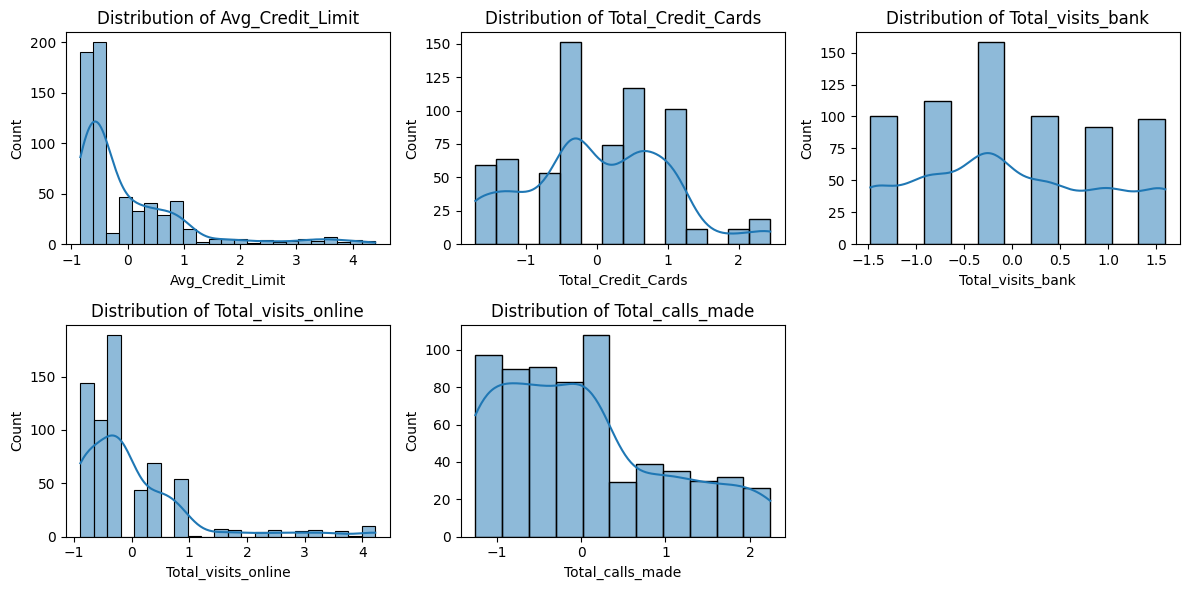

In [10]:
#Distribution of features
plt.figure(figsize=(12, 6))
for i, feature in enumerate(features, 1):
    plt.subplot(2, 3, i)
    sns.histplot(x_scaled_df[feature], kde=True)
    plt.title(f'Distribution of {feature}')
plt.tight_layout()
plt.show()

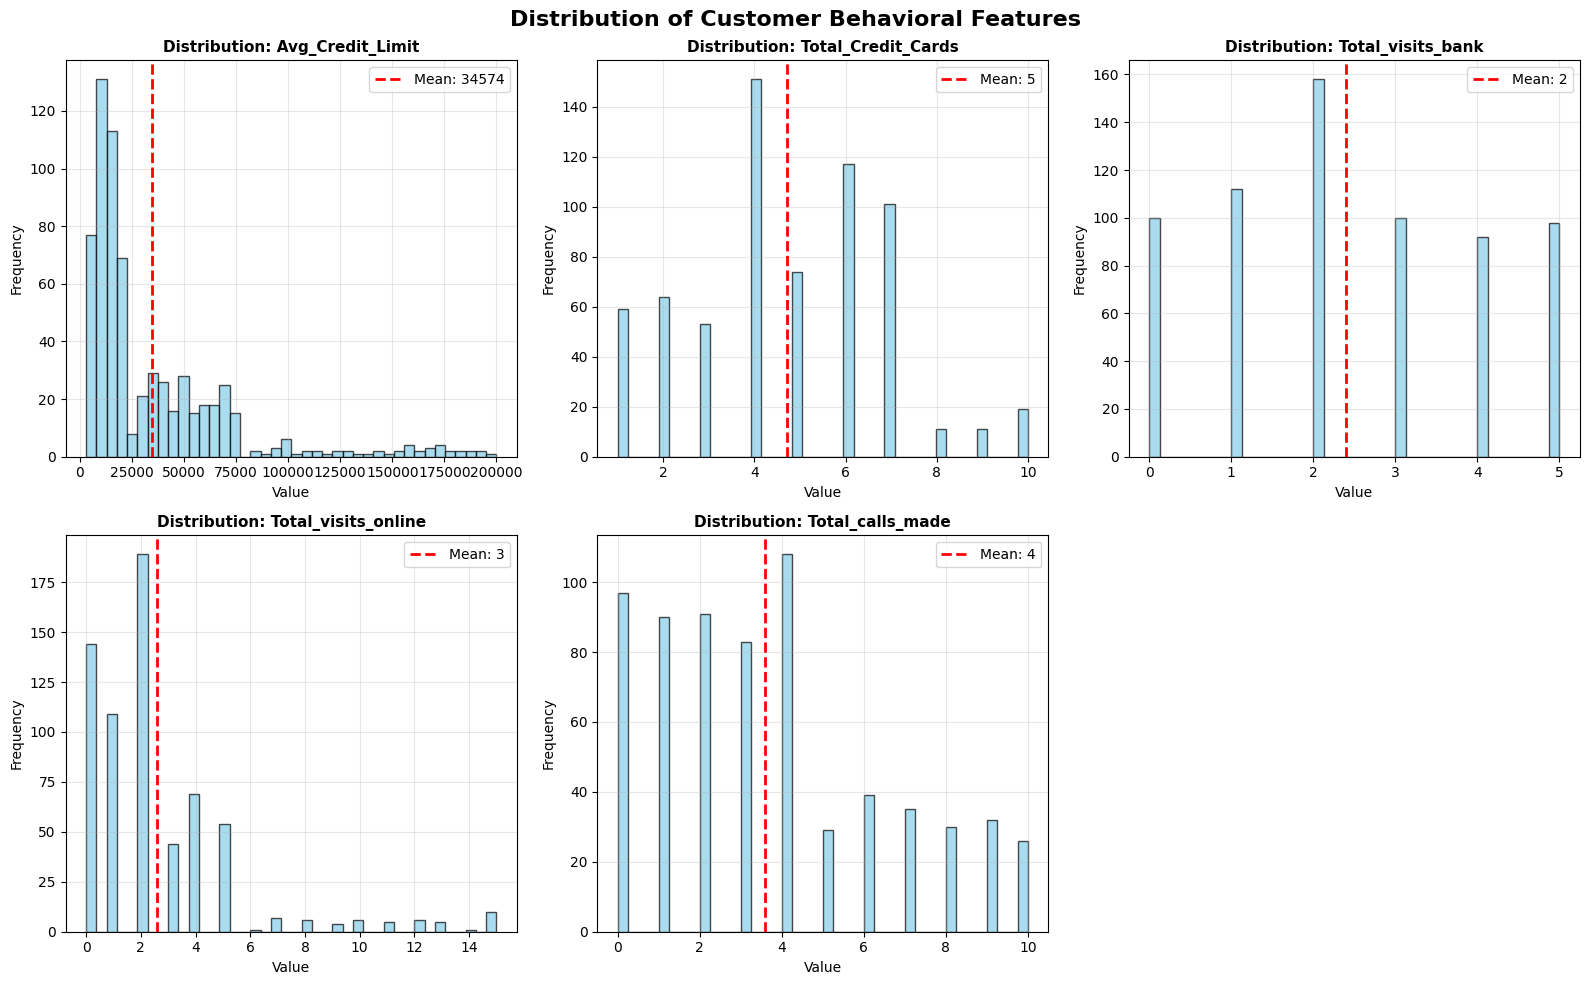

✓ Distribution plots created!


In [11]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Distribution of Customer Behavioral Features', fontsize=16, fontweight='bold')

for idx, feature in enumerate(features):
    row = idx // 3
    col = idx % 3

    # Create histogram
    axes[row, col].hist(x[:, idx], bins=40, color='skyblue', edgecolor='black', alpha=0.7)
    axes[row, col].set_title(f'Distribution: {feature}', fontweight='bold', fontsize=11)
    axes[row, col].set_xlabel('Value')
    axes[row, col].set_ylabel('Frequency')
    axes[row, col].grid(True, alpha=0.3)

    # Add statistics to plot
    mean_val = x[:, idx].mean()
    axes[row, col].axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.0f}')
    axes[row, col].legend()

# Hide the extra subplot
axes[1, 2].set_visible(False)

plt.tight_layout()
plt.show()

print("✓ Distribution plots created!")

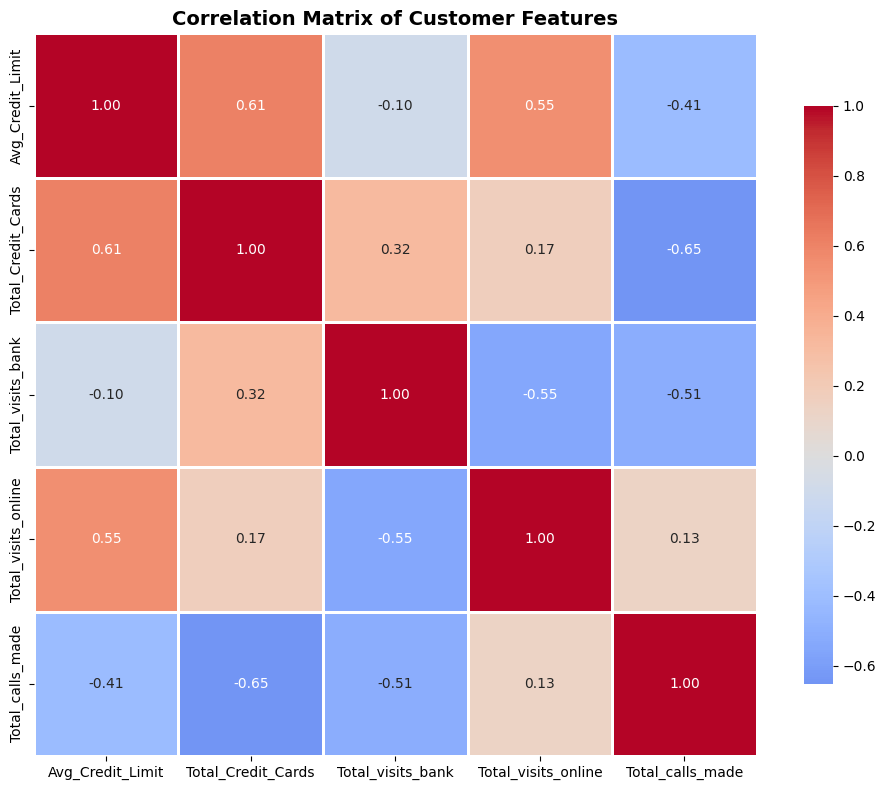

✓ Correlation heatmap created!


In [12]:
#Correlation Analysis, Creating correlation heatmap

fig, ax = plt.subplots(figsize=(10, 8))
correlation_matrix = pd.DataFrame(x, columns=features).corr()

# Create heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=2, cbar_kws={"shrink": 0.8}, ax=ax, fmt='.2f')
plt.title('Correlation Matrix of Customer Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("✓ Correlation heatmap created!")

## 🎯 STEP 5: FINDING OPTIMAL EPSILON USING K-DISTANCE GRAPH

### Understanding the K-Distance Graph

The K-distance graph shows the distance to the k-th nearest neighbor for each point.
The "elbow" or "knee" point in this graph suggests a good epsilon value.

In [13]:
print("🎯 FINDING OPTIMAL EPSILON")
print("="*80)

# Calculate k-distance for each point
# k = min_samples = 2 × number_of_features
k = 2 * len(features)
print(f"\nUsing k = {k} (2 × {len(features)} features)")

# Find k nearest neighbors
neighbors = NearestNeighbors(n_neighbors=k)
neighbors_fit = neighbors.fit(x_scaled)
distances, indices = neighbors_fit.kneighbors(x_scaled)

# Sort distances to the k-th nearest neighbor
distances = np.sort(distances[:, k-1], axis=0)

print(f"\nK-distance statistics:")
print(f"  • Min: {distances.min():.3f}")
print(f"  • 25th percentile: {np.percentile(distances, 25):.3f}")
print(f"  • Median (50th): {np.percentile(distances, 50):.3f}")
print(f"  • 75th percentile: {np.percentile(distances, 75):.3f}")
print(f"  • Max: {distances.max():.3f}")

🎯 FINDING OPTIMAL EPSILON

Using k = 10 (2 × 5 features)

K-distance statistics:
  • Min: 0.396
  • 25th percentile: 0.596
  • Median (50th): 0.683
  • 75th percentile: 0.733
  • Max: 2.112


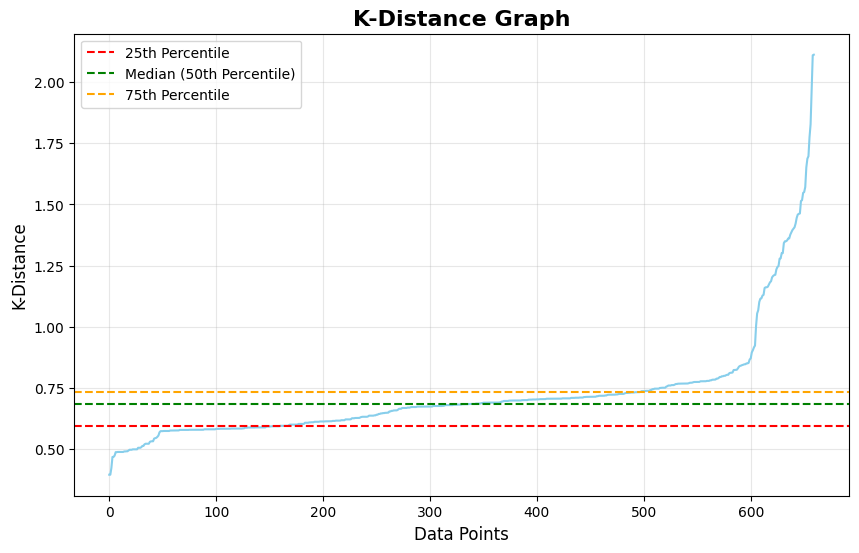

In [14]:
# Plot K Distance Graph
plt.figure(figsize=(10, 6))
plt.plot(distances, color='skyblue')
plt.title('K-Distance Graph', fontsize=16, fontweight='bold')
plt.xlabel('Data Points', fontsize=12)
plt.ylabel('K-Distance', fontsize=12)
plt.grid(True, alpha=0.3)

# Add reference lines for potential epsilon values
plt.axhline(y=np.percentile(distances, 25), color='red', linestyle='--', label='25th Percentile')
plt.axhline(y=np.percentile(distances, 50), color='green', linestyle='--', label='Median (50th Percentile)')
plt.axhline(y=np.percentile(distances, 75), color='orange', linestyle='--', label='75th Percentile')

plt.legend()
plt.show()

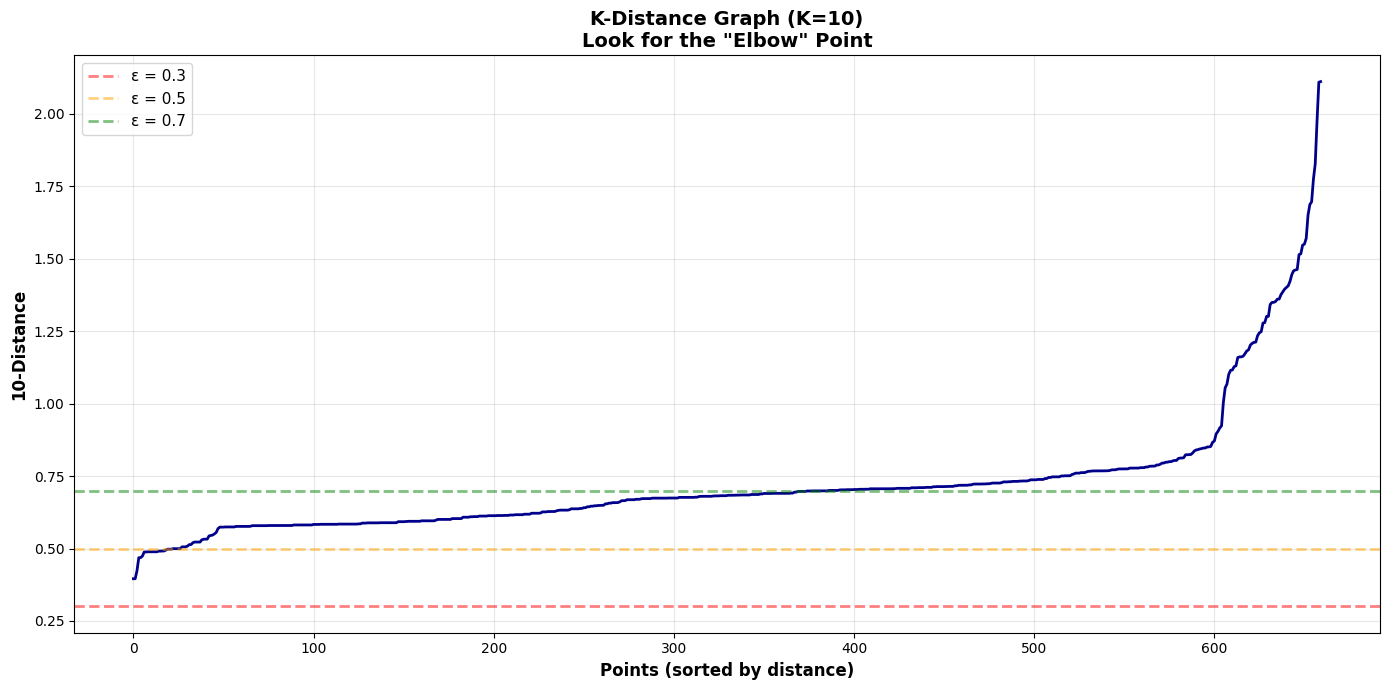


💡 HOW TO READ THIS GRAPH

1. FLAT REGION (bottom-left): Dense clusters
   → These points have many close neighbors

2. KNEE/ELBOW POINT (middle): Transition zone
   → This is where clustering behavior changes
   → Good epsilon candidates are here

3. STEEP REGION (top-right): Outliers/noise
   → Isolated points with few neighbors



In [15]:
# Plot k-distance graph
fig, ax = plt.subplots(figsize=(14, 7))

ax.plot(distances, linewidth=2, color='darkblue')
ax.set_xlabel('Points (sorted by distance)', fontsize=12, fontweight='bold')
ax.set_ylabel(f'{k}-Distance', fontsize=12, fontweight='bold')
ax.set_title(f'K-Distance Graph (K={k})\nLook for the "Elbow" Point',
             fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)

# Add reference lines for potential epsilon values
eps_candidates = [0.3, 0.5, 0.7]
colors = ['red', 'orange', 'green']

for eps, color in zip(eps_candidates, colors):
    ax.axhline(y=eps, color=color, linestyle='--', alpha=0.5, linewidth=2, label=f'ε = {eps}')

ax.legend(fontsize=11, loc='upper left')
plt.tight_layout()
plt.show()

print("\n💡 HOW TO READ THIS GRAPH")
print("="*80)
print("""
1. FLAT REGION (bottom-left): Dense clusters
   → These points have many close neighbors

2. KNEE/ELBOW POINT (middle): Transition zone
   → This is where clustering behavior changes
   → Good epsilon candidates are here

3. STEEP REGION (top-right): Outliers/noise
   → Isolated points with few neighbors
""")

## 🚀 STEP 6: APPLYING DBSCAN CLUSTERING

Now we apply DBSCAN with chosen parameters.

In [16]:
print("🚀 APPLYING DBSCAN")
print("="*80)

# Choose parameters based on k-distance graph
eps = 0.5                    # Epsilon - adjust based on your k-distance graph
min_samples = k              # Minimum samples = 2 × features
metric = 'euclidean'         # Distance metric

print(f"\nDBSCAN Parameters:")
print(f"  • Epsilon (ε): {eps}")
print(f"  • Min Samples: {min_samples}")
print(f"  • Metric: {metric}")

# Initialize DBSCAN
dbscan = DBSCAN(eps=eps, min_samples=min_samples, metric=metric)

# Fit and predict
clusters = dbscan.fit_predict(x_scaled)

print("\n✓ Clustering completed!")

# Calculate cluster statistics
n_clusters = len(set(clusters)) - (1 if -1 in clusters else 0)
n_noise = list(clusters).count(-1)
n_clustered = len(clusters) - n_noise

print(f"\n📊 CLUSTERING RESULTS")
print("="*80)
print(f"Number of Clusters: {n_clusters}")
print(f"Number of Noise Points: {n_noise}")
print(f"Number of Clustered Points: {n_clustered}")
print(f"Clustering Efficiency: {n_clustered/len(clusters)*100:.2f}%")
print(f"Noise Ratio: {n_noise/len(clusters)*100:.2f}%")

🚀 APPLYING DBSCAN

DBSCAN Parameters:
  • Epsilon (ε): 0.5
  • Min Samples: 10
  • Metric: euclidean

✓ Clustering completed!

📊 CLUSTERING RESULTS
Number of Clusters: 6
Number of Noise Points: 566
Number of Clustered Points: 94
Clustering Efficiency: 14.24%
Noise Ratio: 85.76%


In [17]:
# Cluster distribution
print("\n📈 CLUSTER DISTRIBUTION")
print("="*80)

cluster_counts = pd.Series(clusters).value_counts().sort_index()

for cluster_id, count in cluster_counts.items():
    percentage = count / len(clusters) * 100
    if cluster_id == -1:
        print(f"Noise Points: {count:,} ({percentage:.2f}%)")
    else:
        print(f"Cluster {cluster_id}: {count:,} ({percentage:.2f}%)")


📈 CLUSTER DISTRIBUTION
Noise Points: 566 (85.76%)
Cluster 0: 16 (2.42%)
Cluster 1: 21 (3.18%)
Cluster 2: 10 (1.52%)
Cluster 3: 17 (2.58%)
Cluster 4: 20 (3.03%)
Cluster 5: 10 (1.52%)


## 📈 STEP 7: EVALUATION & QUALITY METRICS

### Understanding Evaluation Metrics

1. **Silhouette Score** (-1 to +1): How similar points are to their own cluster
2. **Davies-Bouldin Index**: Average similarity between clusters (lower is better)
3. **Calinski-Harabasz Index**: Ratio of cluster separation (higher is better)

print("📈 EVALUATION METRICS")
print("="*80)

# For evaluation, exclude noise points
mask = clusters != -1

if n_clusters > 1 and mask.sum() > 1:
    # Silhouette Score
    silhouette_avg = silhouette_score(X_scaled[mask], clusters[mask])
    print(f"\nSilhouette Score: {silhouette_avg:.4f}")
    print("  Range: -1 (bad) to +1 (perfect)")
    
    if silhouette_avg > 0.7:
        print("  ✓ Excellent clustering!")
    elif silhouette_avg > 0.5:
        print("  ✓ Good clustering")
    elif silhouette_avg > 0.3:
        print("  ⚠ Fair clustering - consider tuning")
    elif silhouette_avg > 0:
        print("  ✗ Poor clustering - adjust parameters")
    else:
        print("  ✗ Very poor - likely wrong assignments")
    
    # Davies-Bouldin Index (lower is better)
    db_index = davies_bouldin_score(X_scaled[mask], clusters[mask])
    print(f"\nDavies-Bouldin Index: {db_index:.4f}")
    print("  Lower values indicate better cluster separation")
    
    # Calinski-Harabasz Index (higher is better)
    ch_index = calinski_harabasz_score(X_scaled[mask], clusters[mask])
    print(f"\nCalinski-Harabasz Index: {ch_index:.4f}")
    print("  Higher values indicate better defined clusters")
else:
    print("\n⚠ Cannot calculate metrics - need at least 2 clusters with points")

## 🎨 STEP 8: VISUALIZING CLUSTERS

📊 Creating 2D PCA visualization...


/tmp/ipykernel_658/4032115827.py:21: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(x_pca_2d[mask, 0], x_pca_2d[mask, 1],


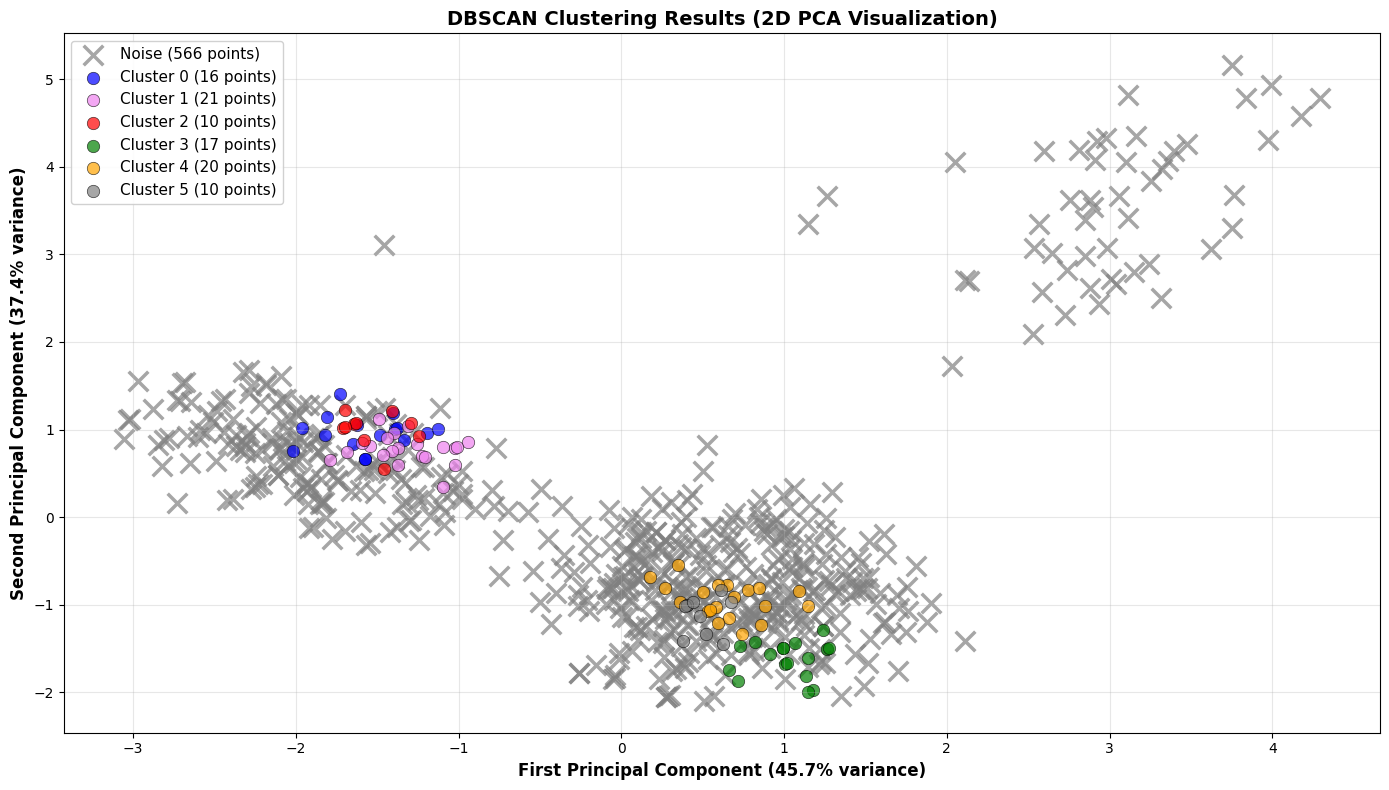

✓ 2D visualization created!
  Total variance explained: 83.16%


In [18]:
from sklearn.decomposition import PCA
# 8.1: 2D Visualization using PCA
print("📊 Creating 2D PCA visualization...")

# Apply PCA to reduce to 2 dimensions
pca_2d = PCA(n_components=2, random_state=42)
x_pca_2d = pca_2d.fit_transform(x_scaled)

# Create scatter plot
fig, ax = plt.subplots(figsize=(14, 8))

# Define colors
colors = ['Blue', 'Violet', 'Red', 'Green', 'Orange', 'Grey', 'Yellow']

# Plot clusters
for cluster_id in sorted(set(clusters)):
    mask = clusters == cluster_id

    if cluster_id == -1:
        # Plot noise points
        ax.scatter(x_pca_2d[mask, 0], x_pca_2d[mask, 1],
                  c='#808080', marker='x', s=200, linewidths=2.5,
                  label=f'Noise ({mask.sum()} points)', alpha=0.7, edgecolors='black')
    else:
        # Plot cluster points
        color = colors[cluster_id % len(colors)]
        ax.scatter(x_pca_2d[mask, 0], x_pca_2d[mask, 1],
                  c=color, s=80, alpha=0.7,
                  label=f'Cluster {cluster_id} ({mask.sum()} points)',
                  edgecolors='black', linewidth=0.5)

ax.set_xlabel(f'First Principal Component ({pca_2d.explained_variance_ratio_[0]*100:.1f}% variance)',
             fontsize=12, fontweight='bold')
ax.set_ylabel(f'Second Principal Component ({pca_2d.explained_variance_ratio_[1]*100:.1f}% variance)',
             fontsize=12, fontweight='bold')
ax.set_title('DBSCAN Clustering Results (2D PCA Visualization)',
            fontsize=14, fontweight='bold')
ax.legend(loc='best', fontsize=11, framealpha=0.9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"✓ 2D visualization created!")
print(f"  Total variance explained: {pca_2d.explained_variance_ratio_.sum()*100:.2f}%")

## 🔍 STEP 9: DETAILED CLUSTER ANALYSIS

In [19]:
# Add cluster labels to original dataframe
df['Cluster'] = clusters

print("🔍 DETAILED CLUSTER ANALYSIS")
print("="*80)

# Analyze each cluster
for cluster_id in sorted(set(clusters)):
    if cluster_id == -1:
        print(f"\n🔴 NOISE POINTS (Cluster ID: -1)")
        print("-" * 80)
    else:
        print(f"\n🟢 CLUSTER {cluster_id}")
        print("-" * 80)

    # Get cluster data
    cluster_data = df[df['Cluster'] == cluster_id][features]

    print(f"\nNumber of Points: {len(cluster_data):,}")
    print(f"Percentage of Total: {len(cluster_data)/len(df)*100:.2f}%")

    # Show detailed statistics
    print(f"\n{'Feature':<25} {'Mean':>12} {'Std':>12} {'Min':>12} {'Max':>12}")
    print("-" * 65)

    for feature in features:
        mean_val = cluster_data[feature].mean()
        std_val = cluster_data[feature].std()
        min_val = cluster_data[feature].min()
        max_val = cluster_data[feature].max()

        print(f"{feature:<25} {mean_val:>12.2f} {std_val:>12.2f} {min_val:>12.2f} {max_val:>12.2f}")

    # Compare with overall mean
    if cluster_id != -1:
        print(f"\nComparison with Dataset Average (% difference):")
        print("-" * 65)

        for feature in features:
            cluster_mean = cluster_data[feature].mean()
            overall_mean = df[features][feature].mean()
            diff_pct = ((cluster_mean - overall_mean) / overall_mean * 100) if overall_mean != 0 else 0

            arrow = "↑" if diff_pct > 0 else "↓" if diff_pct < 0 else "="
            print(f"  {arrow} {feature:<22} {diff_pct:+7.1f}%")

🔍 DETAILED CLUSTER ANALYSIS

🔴 NOISE POINTS (Cluster ID: -1)
--------------------------------------------------------------------------------

Number of Points: 566
Percentage of Total: 85.76%

Feature                           Mean          Std          Min          Max
-----------------------------------------------------------------
Avg_Credit_Limit              37885.16     39598.24      3000.00    200000.00
Total_Credit_Cards                4.75         2.23         1.00        10.00
Total_visits_bank                 2.42         1.60         0.00         5.00
Total_visits_online               2.60         3.10         0.00        15.00
Total_calls_made                  3.58         2.91         0.00        10.00

🟢 CLUSTER 0
--------------------------------------------------------------------------------

Number of Points: 16
Percentage of Total: 2.42%

Feature                           Mean          Std          Min          Max
--------------------------------------------------

## 🎚️ STEP 10: PARAMETER TUNING & OPTIMIZATION

In [21]:
print("🎚️ PARAMETER TUNING & SENSITIVITY ANALYSIS")
print("="*80)

# Test different parameter combinations
epsilon_values = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8]
min_samples_values = [5, 10, 15, 20]

results = []

print("\nTesting parameter combinations...\n")
print(f"{'ε':<6} {'min_s':<8} {'Clusters':<10} {'Noise':<10} {'Noise%':<8} {'Silhouette':<12}")
print("-" * 60)

for eps_val in epsilon_values:
    for min_s in min_samples_values:
        # Apply DBSCAN
        dbscan_temp = DBSCAN(eps=eps_val, min_samples=min_s, metric='euclidean')
        clusters_temp = dbscan_temp.fit_predict(x_scaled)

        # Calculate metrics
        n_clusters_temp = len(set(clusters_temp)) - (1 if -1 in clusters_temp else 0)
        n_noise_temp = list(clusters_temp).count(-1)
        noise_ratio = n_noise_temp / len(clusters_temp) * 100

        # Silhouette score
        mask_temp = clusters_temp != -1
        if n_clusters_temp > 1 and mask_temp.sum() > 1:
            sil_score = silhouette_score(x_scaled[mask_temp], clusters_temp[mask_temp])
        else:
            sil_score = -999

        results.append({
            'eps': eps_val,
            'min_samples': min_s,
            'n_clusters': n_clusters_temp,
            'n_noise': n_noise_temp,
            'noise_ratio': noise_ratio,
            'silhouette': sil_score
        })

        sil_str = f"{sil_score:.4f}" if sil_score > -1 else "N/A"
        print(f"{eps_val:<6.1f} {min_s:<8} {n_clusters_temp:<10} {n_noise_temp:<10} {noise_ratio:<8.1f} {sil_str:<12}")

results_df = pd.DataFrame(results)
print("\n✓ Parameter tuning complete!")

🎚️ PARAMETER TUNING & SENSITIVITY ANALYSIS

Testing parameter combinations...

ε      min_s    Clusters   Noise      Noise%   Silhouette  
------------------------------------------------------------
0.3    5        0          660        100.0    N/A         
0.3    10       0          660        100.0    N/A         
0.3    15       0          660        100.0    N/A         
0.3    20       0          660        100.0    N/A         
0.4    5        25         477        72.3     0.4647      
0.4    10       1          650        98.5     N/A         
0.4    15       0          660        100.0    N/A         
0.4    20       0          660        100.0    N/A         
0.5    5        24         205        31.1     0.0270      
0.5    10       6          566        85.8     0.3888      
0.5    15       0          660        100.0    N/A         
0.5    20       0          660        100.0    N/A         
0.6    5        8          82         12.4     -0.0020     
0.6    10       9   

In [22]:
# Find best parameters
print("\n💡 TUNING INSIGHTS")
print("="*80)

# Filter valid results (with meaningful clustering)
valid_results = results_df[(results_df['n_clusters'] > 0) & (results_df['silhouette'] > -1)]

if len(valid_results) > 0:
    # Best silhouette score
    best_silhouette_idx = valid_results['silhouette'].idxmax()
    best_silhouette = valid_results.loc[best_silhouette_idx]

    print(f"\n🏆 Best Silhouette Score:")
    print(f"   Parameters: ε={best_silhouette['eps']}, min_samples={best_silhouette['min_samples']}")
    print(f"   Score: {best_silhouette['silhouette']:.4f}")
    print(f"   Clusters: {int(best_silhouette['n_clusters'])}, Noise: {best_silhouette['noise_ratio']:.1f}%")

    # Balanced approach
    balanced = valid_results[
        (valid_results['noise_ratio'] < 10) &
        (valid_results['n_clusters'] >= 2) &
        (valid_results['n_clusters'] <= 5)
    ].sort_values('silhouette', ascending=False)

    if len(balanced) > 0:
        print(f"\n⚖️ Balanced Approach (low noise + reasonable clusters):")
        best_balanced = balanced.iloc[0]
        print(f"   Parameters: ε={best_balanced['eps']}, min_samples={best_balanced['min_samples']}")
        print(f"   Score: {best_balanced['silhouette']:.4f}")
        print(f"   Clusters: {int(best_balanced['n_clusters'])}, Noise: {best_balanced['noise_ratio']:.1f}%")


💡 TUNING INSIGHTS

🏆 Best Silhouette Score:
   Parameters: ε=0.8, min_samples=5.0
   Score: 0.5445
   Clusters: 2, Noise: 6.7%

⚖️ Balanced Approach (low noise + reasonable clusters):
   Parameters: ε=0.8, min_samples=5.0
   Score: 0.5445
   Clusters: 2, Noise: 6.7%


## 💾 STEP 11: SAVING RESULTS

In [28]:
print("💾 SAVING RESULTS")
print("="*80)

# Save clustered data
output_df = df.copy()
output_df.to_csv('credit_card_customers_clustered.csv', index=False)
print("✓ Clustered data saved to 'credit_card_customers_clustered.csv'")

# Create summary report
summary = f"""
DBSCAN CLUSTERING ANALYSIS - SUMMARY REPORT
{'='*60}

DATASET INFORMATION:
  Total Customers: {len(df):,}
  Features Used: {len(features)}
  Features: {", ".join(features)}

CLUSTERING PARAMETERS:
  Epsilon (ε): {eps}
  Min Samples: {min_samples}
  Metric: euclidean

RESULTS:
  Number of Clusters: {n_clusters}
  Number of Noise Points: {n_noise}
  Noise Ratio: {n_noise/len(clusters)*100:.2f}%
  Silhouette Score: {f"{best_silhouette['silhouette']:.4f}" if n_clusters > 1 and mask.sum() > 1 else 'N/A'}

CLUSTER DISTRIBUTION:
"""

for cluster_id in sorted(set(clusters)):
    count = sum(clusters == cluster_id)
    percentage = count / len(clusters) * 100
    if cluster_id == -1:
        summary += f"\n  Noise Points: {count:,} ({percentage:.1f}%)"
    else:
        summary += f"\n  Cluster {cluster_id}: {count:,} ({percentage:.1f}%)"

print(summary)
print("\n✓ Summary report created!")

💾 SAVING RESULTS
✓ Clustered data saved to 'credit_card_customers_clustered.csv'

DBSCAN CLUSTERING ANALYSIS - SUMMARY REPORT

DATASET INFORMATION:
  Total Customers: 660
  Features Used: 5
  Features: Avg_Credit_Limit, Total_Credit_Cards, Total_visits_bank, Total_visits_online, Total_calls_made

CLUSTERING PARAMETERS:
  Epsilon (ε): 0.5
  Min Samples: 10
  Metric: euclidean

RESULTS:
  Number of Clusters: 6
  Number of Noise Points: 566
  Noise Ratio: 85.76%
  Silhouette Score: 0.5445

CLUSTER DISTRIBUTION:

  Noise Points: 566 (85.8%)
  Cluster 0: 16 (2.4%)
  Cluster 1: 21 (3.2%)
  Cluster 2: 10 (1.5%)
  Cluster 3: 17 (2.6%)
  Cluster 4: 20 (3.0%)
  Cluster 5: 10 (1.5%)

✓ Summary report created!


## 🎯 STEP 12: BUSINESS INSIGHTS & RECOMMENDATIONS

In [29]:
print("🎯 BUSINESS INSIGHTS & RECOMMENDATIONS")
print("="*80)

print("""
📊 KEY FINDINGS:

1. CUSTOMER SEGMENTATION
   • DBSCAN identified distinct customer groups based on behavioral patterns
   • Each cluster represents a unique customer profile
   • Clusters show natural grouping in the data

2. NOISE/OUTLIER ANALYSIS
   • Noise points represent customers with unusual behavior
   • Could be:
     - High-value premium customers (super-users)
     - Dormant/inactive accounts
     - Fraudulent activity
     - Newly acquired customers

3. DENSITY DISTRIBUTION
   • Shows how customers concentrate in behavioral space
   • Dense regions = mainstream customer behavior
   • Sparse regions = niche or anomalous behavior

💡 RECOMMENDATIONS:

FOR MARKETING:
  ✓ Create targeted campaigns for each cluster
  ✓ Personalize product offerings by segment
  ✓ Focus on low-engagement cluster for activation

FOR RISK MANAGEMENT:
  ✓ Monitor noise points for anomalies
  ✓ Investigate high-activity outliers (potential fraud or premium users)
  ✓ Flag unusual behavior patterns

FOR CUSTOMER SERVICE:
  ✓ Tailor service levels by cluster
  ✓ Develop cluster-specific retention strategies
  ✓ Create specialized support for premium clusters

FOR PRODUCT DEVELOPMENT:
  ✓ Develop features for each cluster's needs
  ✓ Use cluster insights for feature prioritization
  ✓ Design UI/UX for different user types

📈 NEXT STEPS:
  1. Validate clusters with domain experts
  2. Create detailed customer personas for each cluster
  3. Develop action plans specific to each segment
  4. Monitor cluster stability over time
  5. Re-run analysis periodically to track changes
""")

print("\n" + "="*80)
print("🎉 CLUSTERING ANALYSIS COMPLETE! 🎉")
print("="*80)

🎯 BUSINESS INSIGHTS & RECOMMENDATIONS

📊 KEY FINDINGS:

1. CUSTOMER SEGMENTATION
   • DBSCAN identified distinct customer groups based on behavioral patterns
   • Each cluster represents a unique customer profile
   • Clusters show natural grouping in the data

2. NOISE/OUTLIER ANALYSIS
   • Noise points represent customers with unusual behavior
   • Could be:
     - High-value premium customers (super-users)
     - Dormant/inactive accounts
     - Fraudulent activity
     - Newly acquired customers

3. DENSITY DISTRIBUTION
   • Shows how customers concentrate in behavioral space
   • Dense regions = mainstream customer behavior
   • Sparse regions = niche or anomalous behavior

💡 RECOMMENDATIONS:

FOR MARKETING:
  ✓ Create targeted campaigns for each cluster
  ✓ Personalize product offerings by segment
  ✓ Focus on low-engagement cluster for activation

FOR RISK MANAGEMENT:
  ✓ Monitor noise points for anomalies
  ✓ Investigate high-activity outliers (potential fraud or premium users)

## 📚 Additional Resources & Next Steps

In [30]:
print("📚 LEARNING RESOURCES")
print("="*80)

resources = {
    "Official Documentation": [
        "Scikit-Learn DBSCAN: https://scikit-learn.org/stable/modules/clustering.html#dbscan",
        "Scikit-Learn Preprocessing: https://scikit-learn.org/stable/modules/preprocessing.html",
    ],
    "Related Algorithms": [
        "HDBSCAN - Hierarchical variant with varying densities",
        "K-Means - For spherical clusters with fixed K",
        "Agglomerative Clustering - Hierarchical approach",
    ],
    "Advanced Topics": [
        "Anomaly detection using DBSCAN noise points",
        "High-dimensional clustering and curse of dimensionality",
        "Ensemble clustering methods",
    ]
}

for category, items in resources.items():
    print(f"\n{category}:")
    for item in items:
        print(f"  • {item}")

print("\n" + "="*80)
print("✨ Thank you for following this tutorial! ✨")
print("="*80)

📚 LEARNING RESOURCES

Official Documentation:
  • Scikit-Learn DBSCAN: https://scikit-learn.org/stable/modules/clustering.html#dbscan
  • Scikit-Learn Preprocessing: https://scikit-learn.org/stable/modules/preprocessing.html

Related Algorithms:
  • HDBSCAN - Hierarchical variant with varying densities
  • K-Means - For spherical clusters with fixed K
  • Agglomerative Clustering - Hierarchical approach

Advanced Topics:
  • Anomaly detection using DBSCAN noise points
  • High-dimensional clustering and curse of dimensionality
  • Ensemble clustering methods

✨ Thank you for following this tutorial! ✨
